<a id="1"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Imports</center></h1>




# Imports

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import shutil
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import random

import scipy as sp
import itertools

from scipy import ndimage
from shutil import copyfile, rmtree



In [2]:
!pip install kagglehub -q

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aneesarom/rider-with-helmet-without-helmet-number-plate")

print("Path to dataset files:", path)

100%|██████████| 74.6M/74.6M [00:03<00:00, 19.9MB/s]

Extracting files...


Path to dataset files: /home/arulipn/.cache/kagglehub/datasets/aneesarom/rider-with-helmet-without-helmet-number-plate/versions/3


In [8]:
!ls -al /home/arulipn/.cache/kagglehub/datasets/aneesarom/rider-with-helmet-without-helmet-number-plate/versions/3

total 24
drwxr-sr-x 4 arulipn users 4096 Mar 17 13:11 .
drwxr-sr-x 3 arulipn users 4096 Mar 17 13:11 ..
-rw-r--r-- 1 arulipn users   46 Mar 17 13:11 classes.txt
-rw-r--r-- 1 arulipn users  111 Mar 17 13:11 coco128.yaml
drwxr-sr-x 4 arulipn users 4096 Mar 17 13:11 train
drwxr-sr-x 4 arulipn users 4096 Mar 17 13:11 val


In [12]:
'''
Basic Learning About YOLO Dataset</center>
    
What does YOLO dataset format look like?
 data_directory/
    ├── images/
    │   ├── image1.jpg
    │   ├── image2.jpg
    │   ├── ...
    │   └── imageN.jpg
    └── labels/
        ├── image1.txt
        ├── image2.txt
        ├── ...
        └── imageN.txt
'''

'\nBasic Learning About YOLO Dataset</center>\n    \nWhat does YOLO dataset format look like?\n data_directory/\n    ├── images/\n    │   ├── image1.jpg\n    │   ├── image2.jpg\n    │   ├── ...\n    │   └── imageN.jpg\n    └── labels/\n        ├── image1.txt\n        ├── image2.txt\n        ├── ...\n        └── imageN.txt\n'

In [9]:
!pip install ultralytics -q

In [13]:
import yaml
import cv2
import torch
torch.cuda.empty_cache()
# Optional: aggressive clear
import gc; gc.collect(); torch.cuda.empty_cache()
!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
!export CUDA_VISIBLE_DEVICES=1

from sklearn.model_selection import train_test_split
from ultralytics import YOLO
from IPython.display import Image, display
import random

# Checking GPU Availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# 1. Preparing the data structure ==============================================

# Source paths (Kaggle input)

from glob import glob
from itertools import chain
from collections import Counter
from pprint import pprint

id2class_map = {
    '0': 'with helmet', 
    '1': 'without helmet', 
    '2': 'rider', 
    '3': 'number_plate'
}
main_path = "/home/arulipn/.cache/kagglehub/datasets/aneesarom/rider-with-helmet-without-helmet-number-plate/versions/3"

def print_data_size(folder_type):
    data_size = len(glob(f'{main_path}/{folder_type}/labels/*.txt'))
    print(f'{folder_type} data count: {data_size}')
    
def print_class_count(folder_type):
    class_list = []
    for file in glob(f'{main_path}/{folder_type}/labels/*.txt'):
        class_list.append([row.split()[0] for row in open(file, "r")])
    counter = Counter(list(chain(*class_list)))
    print(f'-- data class count')
    pprint({f'{k}. {id2class_map[k]}':v for k, v in counter.items()})
    print()

print_data_size('train')
print_class_count('train')
print_data_size('val')
print_class_count('val')  

Using device: cuda
train data count: 104
-- data class count
{'0. with helmet': 64,
 '1. without helmet': 93,
 '2. rider': 120,
 '3. number_plate': 116}

val data count: 20
-- data class count
{'0. with helmet': 13,
 '1. without helmet': 15,
 '2. rider': 23,
 '3. number_plate': 22}



In [14]:
# plot training images
import os
import cv2
from matplotlib import pyplot as plt

main_path = f"/home/arulipn/.cache/kagglehub/datasets/aneesarom/rider-with-helmet-without-helmet-number-plate/versions/3" 

def get_bbox_and_label(image_name, data_type='train', main_path=main_path):
    ''' get bbox and label information from label txt files '''
    
    # read file from path
    lbl_path = os.path.join(main_path, data_type, 'labels', f'{image_name}.txt')
    with open(lbl_path, 'r') as f:
        lines = f.readlines()
    
    # extract bboxes and labels from the label file
    bboxes = [
        [float(n) for n in line.split()[1:]]
        for line in lines
    ]
    labels = [id2class_map[line.split()[0]] for line in lines]
    
    return bboxes, labels
    
def load_image(image_name, data_type='train', main_path=main_path):
    img_path = os.path.join(main_path, data_type, 'images', f'{image_name}.jpg')    
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

def get_bbox_coordinates(img, bbox):
    # reference
    # https://medium.com/@miramnair/yolov7-calculating-the-bounding-box-coordinates-8bab54b97924
    
    img_height, img_width, _ = img.shape
    x_center, y_center, bbox_width, bbox_height = bbox
    
    # calculate the coordinates of the bounding box
    x_center_pixel = x_center * img_width
    y_center_pixel = y_center * img_height
    half_width = bbox_width * img_width / 2
    half_height = bbox_height * img_height / 2
    
    x_min = int(x_center_pixel - half_width)
    y_min = int(y_center_pixel - half_height)
    x_max = int(x_center_pixel + half_width)
    y_max = int(y_center_pixel + half_height)
    
    return x_min, y_min, x_max, y_max

class2color_map = {
    'with helmet': (0,255,128),
    'without helmet': (255,51,51),
    'rider': (51,255,255),
    'number_plate': (224,102,255)
}

def plot_image(image_name, data_type='train', class2color_map=class2color_map):
    img = load_image(image_name=image_name, data_type=data_type)
    bboxes, labels = get_bbox_and_label(image_name=image_name, data_type=data_type)
    for bbox, label in zip(bboxes, labels):
        
        # get bbox and label info
        color = class2color_map[label]
        x_min, y_min, x_max, y_max = get_bbox_coordinates(img, bbox)
        
        # add bounding box with rectangle
        img = cv2.rectangle(img,(x_min,y_min),(x_max,y_max), color, 2)
        
        # add label info
        img = cv2.putText(
                img,
                label,
                (x_min, y_min + 10),
                fontFace = cv2.FONT_HERSHEY_SIMPLEX,
                fontScale = 0.6,
                color = color,
                thickness=2
            )
    plt.imshow(img)
    plt.show()

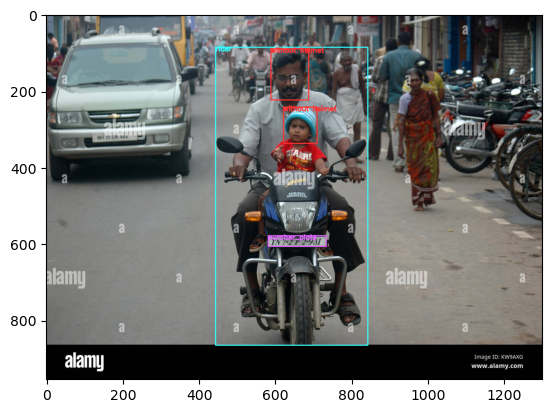

In [15]:
plot_image(image_name='new100')

In [28]:
# 4. Optimized Model Training ==============================================

MODEL_NAME = "yolo11n"  # Using YOLO11n-seg
EPOCHS = 50
IMGSZ = 640
BATCH_SIZE = 16  # Reduce if you get CUDA OOM errors
CONF_THRES = 0.3

# Load model with segmentation-specific settings
model = YOLO(f"{MODEL_NAME}.pt").to(device)

import yaml

# read the content of coco128.yaml
with open(os.path.join(main_path, 'coco128.yaml'), 'r') as file:
    print(file.read())

# creata the yaml based on coco128 for model training
data = {
    'train': '/home/arulipn/.cache/kagglehub/datasets/aneesarom/rider-with-helmet-without-helmet-number-plate/versions/3/train',
    'val': '/home/arulipn/.cache/kagglehub/datasets/aneesarom/rider-with-helmet-without-helmet-number-plate/versions/3/val',
    'nc': 4,
    'names': [
        'with helmet',
        'without helmet',
        'rider',
        'number plate'
    ]
}

with open('/tmp/data.yaml', 'w') as file:
    yaml.dump(data, file)

# check the content of data.yaml
with open('/tmp/data.yaml', 'r') as file:
    print(file.read())

train: /train/images
val: /val/images

nc: 4

names: ["with helmet", "without helmet", "rider", "number plate"]
names:
- with helmet
- without helmet
- rider
- number plate
nc: 4
train: /home/arulipn/.cache/kagglehub/datasets/aneesarom/rider-with-helmet-without-helmet-number-plate/versions/3/train
val: /home/arulipn/.cache/kagglehub/datasets/aneesarom/rider-with-helmet-without-helmet-number-plate/versions/3/val



In [29]:
os.environ['WANDB_MODE'] = "disabled"
DATA_YAML_PATH = '/tmp/data.yaml'

In [30]:

    
def train_model():
    results = model.train(
        data=DATA_YAML_PATH,
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH_SIZE,
        name=f'{MODEL_NAME}_helmet_det_optimized',
        patience=15,
        save=True,
        save_period=10,
        device=device,
        workers=1,  # Reduced for stability
        exist_ok=True,
        optimizer='AdamW',
        lr0=0.001,
        augment=True,  # Keep for training
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        degrees=15,
        scale=0.15,
        flipud=0.15,
        fliplr=0.15,
        mosaic=0.1,
        pretrained=True
    )
    return results

print("\nStarting optimized training...")
train_results = train_model()




Starting optimized training...
Ultralytics 8.4.23 🚀 Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA H100 NVL, 95346MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/tmp/data.yaml, degrees=45, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_helmet_det_optimized, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, over

In [35]:
# 5. Optimized Validation =================================================

def validate_model():
    metrics = model.val(
        data=DATA_YAML_PATH,
        batch=BATCH_SIZE,
        imgsz=IMGSZ,
        conf=0.25,
        iou=0.45,
        device=device,
        split='val',
        mask_ratio=4,
        augment=False,  # Explicitly disable for validation
        plots=True,
        save_json=True,
        save_hybrid=True  # Saves both boxes and masks
    )
    
    print("\nOptimized Validation metrics:")
    print(f"Box mAP50-95: {metrics.box.map:.4f}")
    print(f"Box mAP50: {metrics.box.map50:.4f}")
     
    return metrics

val_metrics = validate_model()



WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.23 🚀 Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA H100 NVL, 95346MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2273.7±1778.2 MB/s, size: 455.8 KB)
val: Scanning /home/arulipn/.cache/kagglehub/datasets/aneesarom/rider-with-helmet-without-helmet-number-plate/versions/3/val/labels.cache... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 8.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 12.4it/s 0.4s.4s
                   all         20         73      0.875      0.879      0.904      0.587
           with helmet         12         13          1      0.922      0.959      0.532
        without helmet         10         15      0.688      0.733      0.755      0.441
                 rider         20         23      0.954      0.907      0.951      0.692
          number plate         20         22      0

In [36]:
# select the best model for checking prediction plot
# the model is saved in best.pt directly after training
model = YOLO('runs/detect/yolo11n_helmet_det_optimized/weights/best.pt')

In [37]:
# use results from `model.predict()` for plotting 
def plot_pred_image(image_name, id2class_map=id2class_map, class2color_map=class2color_map):
    image_path = os.path.join(main_path, 'val', 'images', f'{image_name}.jpg')
    
    # get plot elements (bbox, labels) from `predict()` results
    results = model.predict(image_path)
    r = results[0]
    img = r.orig_img
    bboxes = r.boxes.xyxy.tolist()
    labels = [id2class_map[str(int(c))] for c in r.boxes.cls.tolist()]
    for bbox, label in zip(bboxes, labels):
        # get bbox and label info
        color = class2color_map[label]
        x_min, y_min, x_max, y_max = [int(n) for n in bbox]
        
        # add bounding box with rectangle
        img = cv2.rectangle(img,(x_min,y_min),(x_max,y_max), color, 2)
        
        # add label info
        img = cv2.putText(
                img,
                label,
                (x_min, y_min + 10),
                fontFace = cv2.FONT_HERSHEY_SIMPLEX,
                fontScale = 0.6,
                color = color,
                thickness=2
            )
    plt.imshow(img)
    plt.show()

prediction ↓

image 1/1 /home/arulipn/.cache/kagglehub/datasets/aneesarom/rider-with-helmet-without-helmet-number-plate/versions/3/val/images/new94.jpg: 608x640 1 with helmet, 1 rider, 1 number plate, 10.6ms
Speed: 2.6ms preprocess, 10.6ms inference, 0.9ms postprocess per image at shape (1, 3, 608, 640)


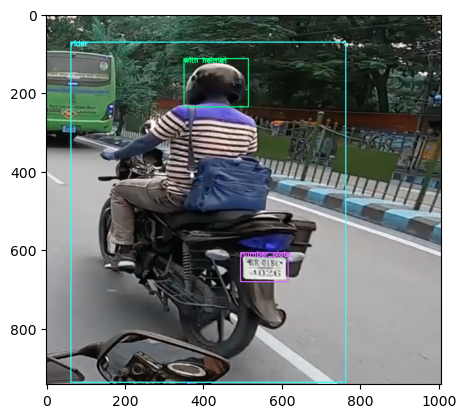

actual image ↓


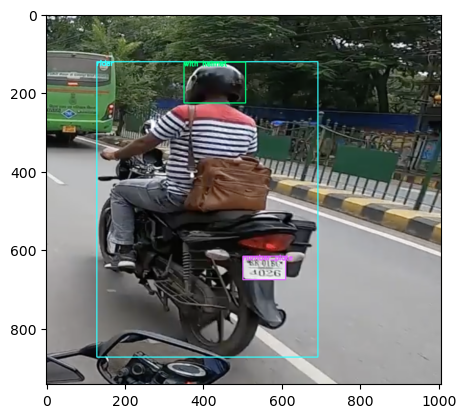

In [34]:
image_name = 'new94'
print('prediction ↓')
plot_pred_image(image_name=image_name)
print('actual image ↓')
plot_image(image_name=image_name, data_type='val')

<a id="5"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Conclusion </center></h1>

# Conclusion 

**Using data augmentation with these hyper-parameters gave us worse results**


**We can Use [transfer learning](https://www.kaggle.com/code/fareselmenshawii/introdution-to-transfer-learning/edit/run/109466477) or a more complex architecture to solve this problem**

**We'll discuss these topics in later notebooks**

<a id="7"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Thank You </center></h1>


    
# Thank You

**Thank you for taking your time and going through this notebook**

**Please let me know if you have any feedback**